In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
df = pd.read_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/infrastructure_bridges/DS3_infrastructure_bridges_5000.csv")
df.head()


,bridge_id,bridge_type,material,year_built,age_years,design_life_years,location,corrosion_environment,corrosion_rate_mm_yr,condition_rating,...,yield_strength_MPa,paris_C,paris_m,original_thickness_mm,remaining_thickness_mm,fatigue_cycles_millions,replacement_cost_M,loan_outstanding_M,last_inspection_date,insurance_premium_K_yr
0,BR-00001,Pedestrian,Reinforced Concrete,1997,27,100,Urban Midwest,Moderate,0.0324,9,...,20,0.000000e+00,0.0,40.4,39.5,5.7,0.89,0.67,2022-06-26,15.9
1,BR-00002,Interstate,Reinforced Concrete,1953,71,100,Urban Midwest,Moderate,0.0320,7,...,20,0.000000e+00,0.0,44.1,41.9,202.7,0.99,0.45,2022-10-16,22.5
2,BR-00003,Local Road,FRP Composite,1989,35,100,Coastal California,Moderate,0.0265,9,...,500,0.000000e+00,0.0,38.0,37.1,150.0,1.52,0.63,2021-05-05,37.8
3,BR-00004,Pedestrian,Prestressed Concrete,1990,34,100,Coastal Florida,Severe,0.0638,7,...,28,0.000000e+00,0.0,66.9,64.8,10.3,0.21,0.12,2021-03-06,2.6
4,BR-00005,Highway,Steel (A588 Weathering),1975,49,75,Urban Midwest,Moderate,0.0199,8,...,345,5.200000e-12,2.8,23.6,22.7,606.6,0.14,0.08,2022-01-06,3.2


In [10]:
def simulate_bridge_risk(row, n_sim=1000):
    results = []
    for _ in range(n_sim):
        # Corrosion effect: thickness loss
        thickness_loss = row['corrosion_rate_mm_yr'] * row['age_years']
        remaining_thickness = row['original_thickness_mm'] - thickness_loss
        
        # Fatigue effect: cycles
        fatigue_factor = np.random.normal(row['fatigue_cycles_millions'], 0.5)
        
        # Failure probability based on condition rating
        fail_prob = (10 - row['condition_rating']) / 10.0
        failed = np.random.rand() < fail_prob
        
        # Financial exposure
        total_cost = row['replacement_cost_M'] + row['loan_outstanding_M']
        total_cost += row['insurance_premium_K_yr'] * row['age_years'] / 1000.0
        
        if failed or remaining_thickness < row['remaining_thickness_mm']:
            total_cost *= 1.3  # penalty multiplier
        
        results.append(total_cost)
    return results


Text(0, 0.5, 'Frequency')

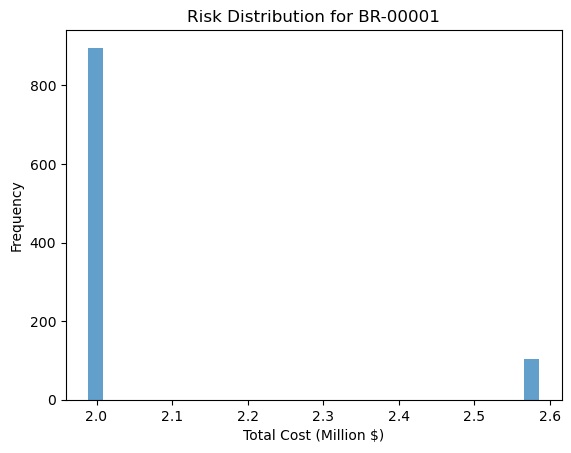

In [12]:
bridge = df.iloc[0]
results = simulate_bridge_risk(bridge)

plt.hist(results, bins=30, alpha=0.7)
plt.title(f"Risk Distribution for {bridge['bridge_id']}")
plt.xlabel("Total Cost (Million $)")
plt.ylabel("Frequency")



In [ ]:
portfolio_results = []
for _, row in df.iterrows():
    portfolio_results.extend(simulate_bridge_risk(row))

plt.hist(portfolio_results, bins=50, alpha=0.7, color='orange')
plt.title("Portfolio Risk Distribution")
plt.xlabel("Total Cost (Million $)")
plt.ylabel("Frequency")



In [ ]:
df['expected_cost'] = df.apply(lambda r: np.mean(simulate_bridge_risk(r)), axis=1)
df['risk_std'] = df.apply(lambda r: np.std(simulate_bridge_risk(r)), axis=1)
df.to_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/infrastructure_bridges/infrastructure_risk.csv", index=False)
